In [1]:
# import os
# os.environ['MPLBACKEND'] = 'Agg'
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)
import sys
# sys.path.append(r"E:\Python code\Machine learning\JupyterNote\Bio_CRC\Data processing\functions")
sys.path.append(r"/ihome/ylee/yiz133/Code/Data processing/functions/")
import mdata_utils 


2026-05-08 12:05:38.797593: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-08 12:05:38.798094: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-08 12:05:38.849848: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-08 12:05:41.711527: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
path = r"/ix1/ylee/Yifan_Zhang/Code_data/Tumor/GSE139555_2019/data/Processed/"
filename = "CD8_DE2500_singleVDJ_emb.h5mu"
DATA_PATH = path + filename

mdata = mu.read(DATA_PATH)
mdata

MuData object with n_obs × n_vars = 14957 × 2500
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned', 'in_two_tissue', 'clone_status', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length'
  uns:	'tcr_embs_feature_names'
  obsm:	'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	14957 x 2500
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'patient', 'source', 'type', 'subtype', 'clone_status'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'hvg', 'log1p', 'neighbors', 'patient_colors', 'pca', 'source_colors', 'subtype_colors', 'type_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'
    airr:	14957 x 0
      obs:	'sample', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'cc_aa_tcrdist', 'chain_indices', 'clone_id', 'ir_dist_aa_identity', 'ir_dist_aa_tcrdist', 'ir_dist_nt_identity'
      obsm:	'airr', 'chain_indices'

In [3]:
mdata.obs['subtype'].value_counts()

subtype
CD8_Tem          3747
CD8_Teff         3284
CD8_Trm_exh_L    2991
CD8_Trm_exh_H    2409
CD8_Trm_exh_M    1335
CD8_Mitosis       462
CD8_Chrom         373
CD8_KLRB1         356
Name: count, dtype: int64

In [4]:
# mdata = mdata[mdata.obs['subtype'].isin(['CD8_Tem', 'CD8_Teff', 'CD8_Trm_exh_L', 
#                               'CD8_Trm_exh_H','CD8_Trm_exh_M'])].copy()
# mdata

In [5]:
pd.DataFrame({
    "CDR3b": mdata.obs["VDJ_1_cdr3_aa"].astype(str),
    "Vb": mdata.obs["VDJ_1_v_call"].astype(str),
    "Jb": mdata.obs["VDJ_1_j_call"].astype(str),
    "CDR3a": mdata.obs["VJ_1_cdr3_aa"].astype(str),
    "condition": mdata.obs["patient"].astype(str),
    "clone_id_size": mdata["airr"].obs["clone_id_size"],
}).to_csv("CD8_singleVDJ_tcr.csv", index=False)

## Clonotype trace

In [6]:
ir.pp.ir_dist(mdata,metric="tcrdist",sequence="aa", cutoff=15)
ir.tl.define_clonotype_clusters(mdata, sequence="aa", metric="tcrdist", receptor_arms="all", dual_ir="any")

In [7]:
obs = mdata.obs.copy()

n_alpha = obs['VJ_1_cdr3_aa'].nunique()
n_beta  = obs['VDJ_1_cdr3_aa'].nunique()

print(f"Unique alpha-chain (VJ) clonotypes:  {n_alpha}")
print(f"Unique beta-chain  (VDJ) clonotypes: {n_beta}")
print(f"Total cells: {len(obs)}")

Unique alpha-chain (VJ) clonotypes:  4529
Unique beta-chain  (VDJ) clonotypes: 4544
Total cells: 14957


In [8]:
# Subset to clonotypes appearing in multiple source tissues AND multiple subtypes
clone_col = 'cc_aa_tcrdist' if 'cc_aa_tcrdist' in mdata['airr'].obs.columns else 'clone_id'
dist_cutoff = 30

obs_all = mdata.obs.copy()
obs_all['_clone'] = mdata['airr'].obs[clone_col].values
obs_all['_source'] = mdata['gex'].obs['source'].values
obs_all['_subtype'] = mdata['gex'].obs['subtype'].values

obs_valid = obs_all.dropna(subset=['_clone', '_source', '_subtype'])

source_nunique = obs_valid.groupby('_clone')['_source'].nunique()
subtype_nunique = obs_valid.groupby('_clone')['_subtype'].nunique()

multi_source = set(source_nunique[source_nunique >= 3].index)
print(f"Clonotypes in 2+ sources:  {len(multi_source)}")

mask = obs_valid['_clone'].isin(multi_source)
mdata_multi = mdata[mask.values].copy()

# Plot clonotype network colored by source and subtype
ir.pp.ir_dist(mdata_multi,metric="tcrdist",sequence="aa",cutoff=dist_cutoff)
ir.tl.define_clonotype_clusters(mdata_multi, sequence="aa", metric="tcrdist", receptor_arms="all", dual_ir="any")

ir.tl.clonotype_network(mdata_multi, min_cells=2, sequence="aa", metric="tcrdist")
_ = ir.pl.clonotype_network(mdata_multi, color="gex:source",
      label_fontsize=5, panel_size=(7, 7), base_size=10)



Clonotypes in 2+ sources:  50


In [9]:
multi_subtype = set(subtype_nunique[subtype_nunique >= 3].index)
print(f"Clonotypes in 2+ subtypes: {len(multi_subtype)}")
mask_type = obs_valid['_clone'].isin(multi_subtype)
mdata_multi = mdata[mask_type.values].copy()

# Plot clonotype network colored by source and subtype
ir.pp.ir_dist(mdata_multi,metric="tcrdist",sequence="aa",cutoff=dist_cutoff)
ir.tl.define_clonotype_clusters(mdata_multi, sequence="aa", metric="tcrdist", receptor_arms="all", dual_ir="any")

ir.tl.clonotype_network(mdata_multi, min_cells=4, sequence="aa", metric="tcrdist")
_ = ir.pl.clonotype_network(mdata_multi, color="gex:subtype",
      label_fontsize=5, panel_size=(7,13), base_size=10)


multi_both = multi_source & multi_subtype

Clonotypes in 2+ subtypes: 413


## VDJ gene usage

In [10]:
# V/J usage heatmap. Columns = subsets. Rows = top-k per subset (deduplicated),
# then filtered to those whose mean proportion across subsets is above the
# mean of all-segment mean proportions (i.e. above-average globally).

import seaborn as sns

k = 5
group_col = "subtype"
min_clones_per_group = 2
min_seg_cells_global = 3
clone_id_col = None

PANELS = [
    ("VJ_1_v_call", "aV"),
    ("VJ_1_j_call", "aJ"),
    ("VDJ_1_v_call", "bV"),
    ("VDJ_1_j_call", "bJ"),
]


def _clone_thresh_groups(obs, group_col, min_clones, clone_id_col):
    if min_clones is None or int(min_clones) <= 0:
        return obs[group_col].unique()
    cid = clone_id_col
    if cid is None:
        if "unique_clone_id" in obs.columns:
            cid = "unique_clone_id"
        elif "clone_id" in obs.columns:
            cid = "clone_id"
    if cid is None or cid not in obs.columns:
        raise KeyError(
            "Clone threshold needs unique_clone_id or clone_id on obs, "
            "or pass clone_id_col / set min_clones_per_group=None."
        )
    nclone = obs.groupby(group_col, observed=True)[cid].nunique()
    return nclone[nclone >= int(min_clones)].index


def _vj_proportion_block(obs, seg_col, group_col, row_prefix, group_totals):
    df = obs[[seg_col, group_col]].copy()
    df[seg_col] = df[seg_col].astype(str)
    bad = df[seg_col].isin(["", "nan", "None", "none", "NaN"]) | df[seg_col].isna()
    df = df[~bad]
    if len(df) == 0:
        return None, None
    ct = pd.crosstab(df[seg_col], df[group_col])
    if ct.shape[0] == 0:
        return None, None
    denom = group_totals.reindex(ct.columns).astype(float).replace(0, np.nan)
    prop = ct.div(denom.values, axis=1)
    prop = prop.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    labels = [f"{row_prefix}|{x}" for x in ct.index.astype(str)]
    ct.index = labels
    prop.index = labels
    return prop, ct


def plot_vj_proportion_heatmaps(
    obs,
    group_col="subtype",
    k=5,
    min_clones_per_group=20,
    min_seg_cells_global=20,
    clone_id_col=None,
):
    keep = list(_clone_thresh_groups(obs, group_col, min_clones_per_group, clone_id_col))
    o = obs[obs[group_col].isin(keep)].copy()
    dropped = sorted(set(obs[group_col].astype(str).unique()) - set(map(str, keep)))
    if dropped:
        print(
            f"Excluded {len(dropped)} {group_col}(s) with <{min_clones_per_group} unique clones: "
            f"{dropped[:10]}{'...' if len(dropped) > 10 else ''}"
        )
    if o.empty or o[group_col].nunique() == 0:
        raise ValueError("No cells left after clone threshold; lower min_clones_per_group.")

    group_totals = o.groupby(group_col, observed=True).size()

    prop_parts, ct_parts = [], []
    for seg_col, prefix in PANELS:
        if seg_col not in o.columns:
            continue
        prop, ct = _vj_proportion_block(o, seg_col, group_col, prefix, group_totals)
        if prop is not None:
            prop_parts.append(prop)
            ct_parts.append(ct)

    if not prop_parts:
        raise ValueError("No V/J columns found on obs.")

    prop_all = pd.concat(prop_parts, axis=0).fillna(0.0)
    ct_all   = pd.concat(ct_parts,   axis=0).fillna(0)

    # Drop segments with too few cells globally
    tot = ct_all.sum(axis=1)
    prop_all = prop_all.loc[tot >= int(min_seg_cells_global)]

    if prop_all.shape[0] == 0:
        raise ValueError("No segments pass min_seg_cells_global.")

    # --- top-k per subset, deduplicated ---
    cats = list(prop_all.columns)
    seen, row_labels, row_arrays = set(), [], []
    for g in cats:
        col = prop_all[g].sort_values(ascending=False)
        added = 0
        for seg, _v in col.items():
            if seg in seen:
                continue
            if added >= int(k):
                break
            seen.add(seg)
            row_labels.append(f"{g}|{seg}")
            row_arrays.append(prop_all.loc[seg].to_numpy(dtype=float))
            added += 1

    if not row_arrays:
        raise ValueError("No rows selected; check k / filters.")

    mat = pd.DataFrame(row_arrays, index=row_labels, columns=cats)

    # --- filter per panel: keep rows whose mean proportion > panel mean
    # (mean computed SEPARATELY for aV, aJ, bV, bJ; denominator = 1/n_subsets).
    # Row label format: "{owning_group}|{panel}|{gene}" -> panel = split("|")[1].
    row_means = mat.mean(axis=1)   # 1/n_subsets * sum(prop) for each row
    panels_of_rows = pd.Series(
        [lbl.split("|")[1] for lbl in mat.index], index=mat.index
    )
    panel_thresholds = row_means.groupby(panels_of_rows).mean()
    keep_mask = pd.Series(False, index=mat.index)
    for panel, thresh in panel_thresholds.items():
        panel_rows = panels_of_rows[panels_of_rows == panel].index
        keep_mask.loc[panel_rows] = row_means.loc[panel_rows] > thresh
    n_before = len(mat)
    mat = mat.loc[keep_mask]
    print("Above-average filter per panel (threshold = mean of row-means within panel):")
    for panel, thresh in panel_thresholds.items():
        n_kept = int((panels_of_rows.loc[keep_mask] == panel).sum())
        n_tot  = int((panels_of_rows == panel).sum())
        print(f"  {panel}: threshold={thresh:.4f}, kept {n_kept}/{n_tot}")
    print(f"Total: kept {len(mat)}/{n_before} rows")

    if mat.empty:
        raise ValueError("All rows removed by above-average filter; lower k or min_seg_cells_global.")

    nrows, ncols = mat.shape
    fig_h = min(40, 0.22 * nrows + 2.5)
    fig_w = min(24, 0.45 * ncols + 4.0)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    vmax = float(np.clip(np.asarray(mat, dtype=float).max(), 0.02, 1.0))
    sns.heatmap(
        mat,
        ax=ax,
        cmap="YlOrRd",
        vmin=0.0,
        vmax=vmax,
        linewidths=0.12,
        linecolor="0.88",
        cbar_kws={"shrink": 0.55, "label": "fraction of cells in subset"},
    )
    ax.set_title(
        f"V/J: top-{k} per {group_col}, deduplicated, above-average"
    )
    ax.set_xlabel(group_col)
    ax.set_ylabel(f"<owning {group_col}> | segment")
    ax.tick_params(axis="y", labelsize=6)
    ax.tick_params(axis="x", labelsize=9)
    plt.tight_layout()
    plt.show()


plot_vj_proportion_heatmaps(
    mdata.obs,
    group_col=group_col,
    k=k,
    min_clones_per_group=min_clones_per_group,
    min_seg_cells_global=min_seg_cells_global,
    clone_id_col=clone_id_col,
)

Above-average filter per panel (threshold = mean of row-means within panel):
  aJ: threshold=0.0399, kept 3/8
  aV: threshold=0.0440, kept 5/12
  bJ: threshold=0.1133, kept 3/8
  bV: threshold=0.0506, kept 5/12
Total: kept 16/40 rows


In [11]:
# UMAP in TCR embedding space (all cells / all clonotype-cluster assignments).
# UMAP hyperparameters are chosen to spread clusters apart in 2D (tight local packs, more global repulsion).

tcr_X = np.asarray(mdata.obsm["tcr_embs"], dtype=np.float64)
tcr_X = tcr_X[:, 2:202]   # only atechley factors

mask = np.isfinite(tcr_X).all(axis=1)
obs_tcr = mdata.obs.loc[mask].copy()

clone_col = "cc_aa_tcrdist" if "cc_aa_tcrdist" in mdata["airr"].obs.columns else None
if clone_col is None:
    raise RuntimeError("Expected mdata['airr'].obs['cc_aa_tcrdist'] — run ir_dist + define_clonotype_clusters above first.")
obs_tcr["clone_cluster"] = mdata["airr"].obs.loc[mask, clone_col].astype("category")

adata_tcr = sc.AnnData(X=tcr_X[mask], obs=obs_tcr)
adata_tcr.var_names = [f"tcr_emb_{i}" for i in range(adata_tcr.n_vars)]

sc.pp.neighbors(adata_tcr, n_neighbors=10, use_rep="X", metric="euclidean")
sc.tl.umap(
    adata_tcr,
    min_dist=0.01,
    spread=2.0,
    random_state=42,
)

sc.pl.umap(
    adata_tcr,
    color=["clone_cluster"],
    ncols=2,
    wspace=0.4,
    frameon=False,
    legend_loc='none'
)


KeyboardInterrupt: 

In [ ]:
sc.pl.umap(
    adata_tcr,
    color=["subtype", "source","clone_status"],
    ncols=3,
    wspace=0.4,
    frameon=False,
)


## TCR sanity check

In [69]:
import importlib
import mdata_utils

# After making changes to mymodule.py:
importlib.reload(mdata_utils)
mdata = mu.read(DATA_PATH)

# Combine 'Tumor_multiSite_clone' and 'NAT_multiSite_clone' in mdata.obs['clone_status'] to 'multiSite_clone'
mdata.obs["clone_status"] = mdata.obs["clone_status"].replace(
    {"Tumor_multiSite_clone": "multiSite_clone", "NAT_multiSite_clone": "multiSite_clone"}
)

pseudotime_adata = sc.read_h5ad(path + "CD8_DE2500_singleVDJ_emb_pseudo.h5ad")
# Merge pseudotime_adata.obs['palantir_pseudotime'] into mdata['gex'].obs based on index
mdata["gex"].obs = mdata["gex"].obs.join(
    pseudotime_adata.obs[["palantir_pseudotime"]],
    how="left"
)
mdata

MuData object with n_obs × n_vars = 14957 × 2500
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned', 'in_two_tissue', 'clone_status', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length'
  uns:	'tcr_embs_feature_names'
  obsm:	'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	14957 x 2500
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'patient', 'source', 'type', 'subtype', 'clone_status', 'palantir_pseudotime'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'hvg', 'log1p', 'neighbors', 'patient_colors', 'pca', 'source_colors', 'subtype_colors', 'type_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'
    airr:	14957 x 0
      obs:	'sample', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'cc_aa_tcrdist', 'chain_indices', 'clone_id', 'ir_dist_aa_identity', 'ir_dist_aa_tcrdist', 'ir_dist_nt_identity'
      obsm:	'airr', 'chain_indices'

In [70]:
# Random selection form each clone
mdata = mdata_utils.select_onecell_per_clone(mdata)
mdata = mdata[mdata['airr'].obs['clone_id_size'] > 1]

In [71]:
# average gex from each clone
# mdata_clone_ave = mdata_utils.aggregate_mdata_by_clone(mdata, clone_col="clone_id")
# mdata = mdata_clone_ave.copy()
# mdata

In [72]:
# gene gradients from each clone
# mdata_clone_grad = mdata_utils.per_clone_gene_slope_mdata(mdata,
#     clone_col="clone_id",
#     min_nonzero_cells=2,
#     # slope_x_col="total_counts",
#     )
# mdata = mdata_clone_grad.copy()

In [73]:
## Mutual information between TCR embeddings and GEX PCA space
from scipy.spatial import cKDTree
from scipy.special import digamma
from sklearn.preprocessing import StandardScaler


# Kraskov MI estimator (Algorithm 1): Kraskov et al., PRE 2004
# I(X;Y) = psi(k) - <psi(nx+1) + psi(ny+1)> + psi(N)

def kraskov_mi(X: np.ndarray, Y: np.ndarray, k: int = 5) -> float:
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    N = len(X)
    assert len(Y) == N
    X = StandardScaler().fit_transform(X)
    Y = StandardScaler().fit_transform(Y)
    Z = np.hstack([X, Y])
    tree_Z = cKDTree(Z)
    dist, _ = tree_Z.query(Z, k + 1, workers=-1, p=np.inf)
    eps = dist[:, -1]
    tree_X = cKDTree(X)
    tree_Y = cKDTree(Y)
    nx = np.array(tree_X.query_ball_point(X, eps - 1e-15, p=np.inf, workers=-1, return_length=True))
    ny = np.array(tree_Y.query_ball_point(Y, eps - 1e-15, p=np.inf, workers=-1, return_length=True))
    return float(digamma(k) - np.mean(digamma(nx) + digamma(ny)) + digamma(N))


def conditional_mi(X, Y, labels, k=5, min_class_size=20):
    # I(X; Y | labels): stratify on label classes, weighted average by class frequency.
    labels = np.asarray(labels)
    classes, counts = np.unique(labels, return_counts=True)
    N = len(X)
    total_mi, total_weight = 0.0, 0.0
    results = {}
    for cls, cnt in zip(classes, counts):
        if cnt < min_class_size:
            continue
        idx = labels == cls
        mi_cls = kraskov_mi(X[idx], Y[idx], k=min(k, cnt // 4))
        weight = cnt / N
        results[cls] = {"mi": mi_cls, "n": int(cnt), "weight": float(weight)}
        total_mi += weight * mi_cls
        total_weight += weight
    results["__weighted_avg__"] = total_mi / total_weight if total_weight > 0 else 0.0
    return results


def mi_bootstrap_ci(X, Y, k=5, n_boot=200, ci=95, seed=42):
    # Bootstrap CI around the MI point estimate.
    rng = np.random.default_rng(seed)
    N = len(X)
    boot_mis = [kraskov_mi(X[rng.integers(0, N, size=N)], Y[rng.integers(0, N, size=N)], k=k)
                for _ in range(n_boot)]
    return {
        "mi":    kraskov_mi(X, Y, k),
        "ci_lo": float(np.percentile(boot_mis, (100 - ci) / 2)),
        "ci_hi": float(np.percentile(boot_mis, 100 - (100 - ci) / 2)),
    }


# ── Centered Kernel Alignment (linear kernel) ────────────────────────────────
# CKA(X,Y) = HSIC(XX^T, YY^T) / sqrt(HSIC(XX^T,XX^T) * HSIC(YY^T,YY^T))
# Efficient via Frobenius norms: HSIC(K,L) = ||X^T Y||_F^2 / (n-1)^2
# (centering absorbed by column-mean subtraction)

def linear_cka(X: np.ndarray, Y: np.ndarray) -> float:
    """Linear CKA between two representation matrices (n_samples × d)."""
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    X = X - X.mean(axis=0)
    Y = Y - Y.mean(axis=0)
    XtY = X.T @ Y
    XtX = X.T @ X
    YtY = Y.T @ Y
    hsic_xy = np.linalg.norm(XtY, "fro") ** 2
    hsic_xx = np.linalg.norm(XtX, "fro") ** 2
    hsic_yy = np.linalg.norm(YtY, "fro") ** 2
    denom = np.sqrt(hsic_xx * hsic_yy)
    return float(hsic_xy / denom) if denom > 0 else 0.0


def conditional_cka(X, Y, labels, min_class_size=20):
    """CKA conditioned on label classes: weighted average over strata."""
    labels = np.asarray(labels)
    classes, counts = np.unique(labels, return_counts=True)
    N = len(X)
    total_cka, total_weight = 0.0, 0.0
    results = {}
    for cls, cnt in zip(classes, counts):
        if cnt < min_class_size:
            continue
        idx = labels == cls
        cka_cls = linear_cka(X[idx], Y[idx])
        weight = cnt / N
        results[cls] = {"cka": cka_cls, "n": int(cnt), "weight": float(weight)}
        total_cka += weight * cka_cls
        total_weight += weight
    results["__weighted_avg__"] = total_cka / total_weight if total_weight > 0 else 0.0
    return results



In [ ]:
# ── Data preparation ────────────────────────────────────────────
# TCR modality: mdata.obsm["tcr_embs"] (Atchley + composition vectors)
# GEX modality: mdata["gex"].obsm["X_pca"]
# Only keep cells present in both and with finite values.

tcr_raw = np.asarray(mdata.obsm["tcr_embs"], dtype=np.float64)
# gex_raw = np.asarray(mdata["gex"].obsm["X_pca"], dtype=np.float64)

# Re-load gex_raw from the original gene expression matrix, then apply PCA
gex_X = np.asarray(mdata["gex"].X, dtype=np.float64)

from sklearn.decomposition import PCA

gex_pca = PCA(n_components=30)
gex_raw = gex_pca.fit_transform(gex_X)

pca = PCA(n_components=30)
tcr_raw = pca.fit_transform(tcr_raw)

finite_mask = np.isfinite(tcr_raw).all(axis=1) & np.isfinite(gex_raw).all(axis=1)
tcr_X = tcr_raw[finite_mask]
gex_Y = gex_raw[finite_mask]
obs_mi = mdata.obs.loc[finite_mask].copy()

print(f"Cells used for MI estimation: {finite_mask.sum()} / {len(finite_mask)}")
print(f"TCR embedding dim: {tcr_X.shape[1]},  GEX PCA dim: {gex_Y.shape[1]}")

# ── Marginal MI: I(TCR_z ; GEX_z) ──────────────────────────────
mi_marginal = kraskov_mi(tcr_X, gex_Y, k=5)
print(f"\nI(TCR_embs ; GEX_pca)          = {mi_marginal:.4f} nats  ({mi_marginal/np.log(2):.4f} bits)")
cka_marginal = linear_cka(tcr_X, gex_Y)
print(f"CKA(TCR_embs ; GEX_pca)        = {cka_marginal:.4f}")


ValueError: setting an array element with a sequence.

In [75]:
## SC level conditions

# ── Conditional MI + CKA given subtype ──────────────────────────
cmi_subtype = conditional_mi(tcr_X, gex_Y, obs_mi["subtype"].to_numpy(), k=5)
print(f"\nI(TCR_embs ; GEX_pca | subtype) = {cmi_subtype['__weighted_avg__']:.4f} nats")
for cls, v in sorted(cmi_subtype.items()):
    if cls == "__weighted_avg__":
        continue
    print(f"  {cls:<30s}  MI={v['mi']:.4f}  n={v['n']}  w={v['weight']:.3f}")
ccka_subtype = conditional_cka(tcr_X, gex_Y, obs_mi["subtype"].to_numpy())
print(f"CKA(TCR_embs ; GEX_pca | subtype) = {ccka_subtype['__weighted_avg__']:.4f}")
for cls, v in sorted(ccka_subtype.items()):
    if cls == "__weighted_avg__":
        continue
    print(f"  {cls:<30s}  CKA={v['cka']:.4f}  n={v['n']}  w={v['weight']:.3f}")

# ── Conditional MI + CKA given source tissue ────────────────────
cmi_source = conditional_mi(tcr_X, gex_Y, obs_mi["source"].to_numpy(), k=5)
print(f"\nI(TCR_embs ; GEX_pca | source)  = {cmi_source['__weighted_avg__']:.4f} nats")
for cls, v in sorted(cmi_source.items()):
    if cls == "__weighted_avg__":
        continue
    print(f"  {cls:<30s}  MI={v['mi']:.4f}  n={v['n']}  w={v['weight']:.3f}")
ccka_source = conditional_cka(tcr_X, gex_Y, obs_mi["source"].to_numpy())
print(f"CKA(TCR_embs ; GEX_pca | source)  = {ccka_source['__weighted_avg__']:.4f}")
for cls, v in sorted(ccka_source.items()):
    if cls == "__weighted_avg__":
        continue
    print(f"  {cls:<30s}  CKA={v['cka']:.4f}  n={v['n']}  w={v['weight']:.3f}")



I(TCR_embs ; GEX_pca | subtype) = 0.0338 nats
  CD8_Chrom                       MI=0.0487  n=203  w=0.041
  CD8_KLRB1                       MI=0.0386  n=260  w=0.053
  CD8_Mitosis                     MI=0.0248  n=231  w=0.047
  CD8_Teff                        MI=0.0428  n=531  w=0.108
  CD8_Tem                         MI=0.0337  n=1311  w=0.266
  CD8_Trm_exh_H                   MI=0.0594  n=651  w=0.132
  CD8_Trm_exh_L                   MI=0.0220  n=1307  w=0.265
  CD8_Trm_exh_M                   MI=0.0155  n=433  w=0.088
CKA(TCR_embs ; GEX_pca | subtype) = 0.0268
  CD8_Chrom                       CKA=0.0412  n=203  w=0.041
  CD8_KLRB1                       CKA=0.0337  n=260  w=0.053
  CD8_Mitosis                     CKA=0.0591  n=231  w=0.047
  CD8_Teff                        CKA=0.0462  n=531  w=0.108
  CD8_Tem                         CKA=0.0168  n=1311  w=0.266
  CD8_Trm_exh_H                   CKA=0.0232  n=651  w=0.132
  CD8_Trm_exh_L                   CKA=0.0169  n=1307  w=0.265

In [76]:
aa

NameError: name 'aa' is not defined

In [ ]:
## Clone level conditions

# ── Conditional MI + CKA given clone_status ─────────────────────
cmi_source = conditional_mi(tcr_X, gex_Y, obs_mi["clone_status"].to_numpy(), k=5)
print(f"\nI(TCR_embs ; GEX_pca | clone_status)   = {cmi_source['__weighted_avg__']:.4f} nats")
for cls, v in sorted(cmi_source.items()):
    if cls == "__weighted_avg__":
        continue
    print(f"  {cls:<30s}  MI={v['mi']:.4f}  n={v['n']}  w={v['weight']:.3f}")
ccka_clone = conditional_cka(tcr_X, gex_Y, obs_mi["clone_status"].to_numpy())
print(f"CKA(TCR_embs ; GEX_pca | clone_status) = {ccka_clone['__weighted_avg__']:.4f}")
for cls, v in sorted(ccka_clone.items()):
    if cls == "__weighted_avg__":
        continue
    print(f"  {cls:<30s}  CKA={v['cka']:.4f}  n={v['n']}  w={v['weight']:.3f}")



I(TCR_embs ; GEX_pca | clone_status)   = 0.0085 nats
  Blood_single                    MI=0.0000  n=294  w=0.060
  NAT_single                      MI=-0.0000  n=1558  w=0.316
  NAT_singleSite_clone            MI=0.1024  n=364  w=0.074
  Tumor_single                    MI=-0.0054  n=1714  w=0.348
  Tumor_singleSite_clone          MI=0.0010  n=457  w=0.093
  multiSite_clone                 MI=0.0248  n=537  w=0.109
CKA(TCR_embs ; GEX_pca | clone_status) = 0.0120
  Blood_single                    CKA=0.0000  n=294  w=0.060
  NAT_single                      CKA=0.0000  n=1558  w=0.316
  NAT_singleSite_clone            CKA=0.0520  n=364  w=0.074
  Tumor_single                    CKA=0.0043  n=1714  w=0.348
  Tumor_singleSite_clone          CKA=0.0337  n=457  w=0.093
  multiSite_clone                 CKA=0.0327  n=537  w=0.109


In [ ]:
# # ── Bootstrap CI for marginal MI (reduce n_boot for speed) ──────
# ci_result = mi_bootstrap_ci(tcr_X, gex_Y, k=5, n_boot=100)
# print(
#     f"\nMarginal MI  {ci_result['mi']:.4f} nats  "
#     f"95% CI [{ci_result['ci_lo']:.4f}, {ci_result['ci_hi']:.4f}]"
# )

In [ ]:
# ── Build cell→clone_id→pseudotime table ─────────────────────────────────
# mdata at this point is clone-aggregate (mdata_clone_grad).
# Reload original cell-level mdata to access per-cell clone_id.
mdata_cell = mu.read(DATA_PATH)

# clone_id lives in the airr modality
clone_id_ser = mdata_cell["airr"].obs["clone_id"].copy()          # index = cell barcode
pt_ser       = pseudotime_adata.obs["palantir_pseudotime"].copy()  # index = cell barcode

cell_df = clone_id_ser.to_frame().join(pt_ser, how="inner")
cell_df = cell_df.dropna(subset=["palantir_pseudotime"])
print(f"Cells with both clone_id and pseudotime: {len(cell_df)}")

# ── For each clone in mdata, collect sorted pseudotime values ────────────────
# Interpolate each clone's pseudotime profile to K evenly-spaced points so
# every clone is represented by the same-length vector.
K = 30  # fixed-length pseudotime profile per clone

pt_lookup = {}   # clone_id -> sorted pseudotime array
for cid, grp in cell_df.groupby("clone_id"):
    pt_lookup[cid] = np.sort(grp["palantir_pseudotime"].to_numpy(dtype=np.float64))

clone_ids = mdata.obs["clone_id"].to_numpy()
tcr_raw   = np.asarray(mdata.obsm["tcr_embs"], dtype=np.float64)

rows_tcr = []
rows_pt  = []
rows_obs = []
for i, cid in enumerate(clone_ids):
    pts = pt_lookup.get(cid)
    if pts is None or len(pts) == 0:
        continue
    # interpolate to K points regardless of clone size
    pts_k = np.interp(np.linspace(0, len(pts) - 1, K),
                      np.arange(len(pts)), pts)
    if not np.isfinite(tcr_raw[i]).all():
        continue
    rows_tcr.append(tcr_raw[i])
    rows_pt.append(pts_k)
    rows_obs.append(i)

tcr_arr = np.array(rows_tcr)
pt_arr  = np.array(rows_pt)            # shape: (n_clones, K)
obs_clone = mdata.obs.iloc[rows_obs].copy()
print(f"Clones with pseudotime profile: {len(tcr_arr)}  (K={K} per clone)")

# ── PCA on TCR embeddings ─────────────────────────────────────────────────────
tcr_clone_pca = PCA(n_components=min(30, tcr_arr.shape[1])).fit_transform(tcr_arr)

# ── Marginal MI / CKA: I(TCR_embs ; pseudotime_vec) ─────────────────────────
mi_clone  = kraskov_mi(tcr_clone_pca, pt_arr, k=3)
cka_clone = linear_cka(tcr_clone_pca, pt_arr)
print(f"\nI(TCR_embs ; pseudotime_vec [K={K}])       = {mi_clone:.4f} nats  ({mi_clone/np.log(2):.4f} bits)")
print(f"CKA(TCR_embs ; pseudotime_vec [K={K}])     = {cka_clone:.4f}")

# ── Conditional MI: I(TCR_embs ; pseudotime_vec | clone_status) ──────────────
cmi_clone_status = conditional_mi(tcr_clone_pca, pt_arr,
                                  obs_clone["clone_status"].to_numpy(), k=3)
print(f"\nI(TCR_embs ; pseudotime_vec | clone_status) = {cmi_clone_status['__weighted_avg__']:.4f} nats")
for cls, v in sorted(cmi_clone_status.items()):
    if cls == "__weighted_avg__":
        continue
    print(f"  {cls:<30s}  MI={v['mi']:.4f}  n={v['n']}  w={v['weight']:.3f}")



Cells with both clone_id and pseudotime: 14957
Clones with pseudotime profile: 4927  (K=30 per clone)

I(TCR_embs ; pseudotime_vec [K=30])       = 0.0146 nats  (0.0211 bits)
CKA(TCR_embs ; pseudotime_vec [K=30])     = 0.0017

I(TCR_embs ; pseudotime_vec | clone_status) = 0.0101 nats
  Blood_single                    MI=-0.0045  n=294  w=0.060
  NAT_single                      MI=0.0042  n=1558  w=0.316
  NAT_singleSite_clone            MI=0.0549  n=364  w=0.074
  Tumor_single                    MI=0.0014  n=1714  w=0.348
  Tumor_singleSite_clone          MI=0.0146  n=457  w=0.093
  multiSite_clone                 MI=0.0290  n=537  w=0.109


## PAGA Trajectory  (useless)

In [ ]:
aa

NameError: name 'aa' is not defined

In [ ]:
# adata_tumor = mdata[mdata.obs['source'] == 'Tumor'].copy()
adata = mdata['gex']


In [ ]:
sc.tl.diffmap(adata, n_comps=20)
sc.pp.neighbors(adata, n_neighbors=20, use_rep="X_diffmap")
sc.tl.umap(adata)

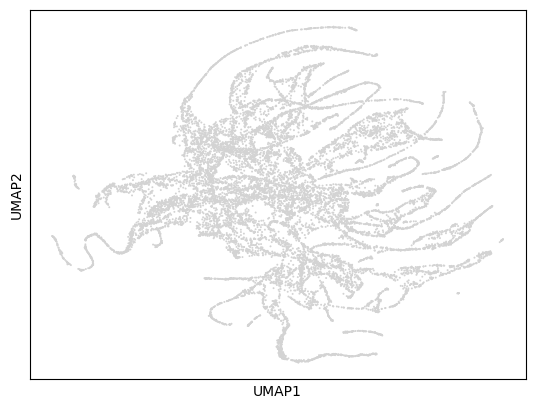

In [ ]:
sc.pl.umap(adata)

In [ ]:
sc.tl.draw_graph(adata)

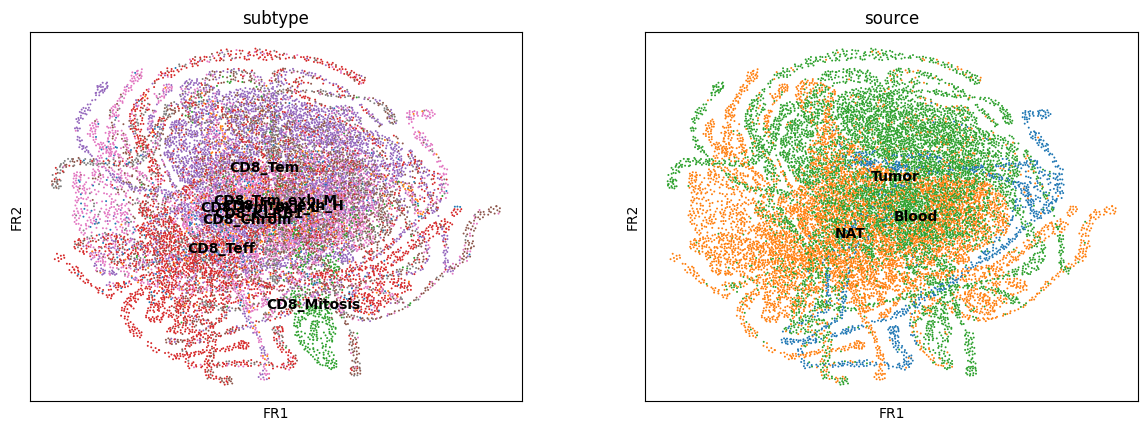

In [ ]:
sc.pl.draw_graph(adata, color=["subtype", "source"], legend_loc="on data")

In [ ]:
sc.tl.leiden(adata)
sc.tl.paga(adata, groups="leiden")

ValueError: Expected `colors` to be of length `65`, found `31`.

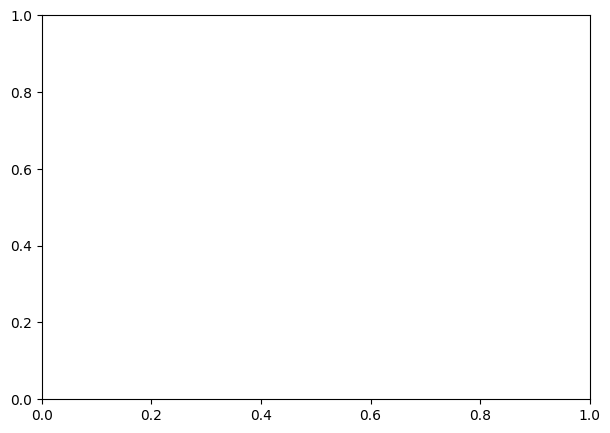

In [ ]:
sc.pl.paga(adata)